# Text Classification

In [4]:
import re
import string
import nltk
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer, PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder
from wordcloud import WordCloud
# Removed 'from gensim.models import Word2Vec' from here as it's not used immediately
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

# Download necessary NLTK data
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
data = pd.read_csv("/content/drive/MyDrive/ai coursework dataset/6. News Category Dataset/news_category.csv", encoding="ISO-8859-1")


# 4.5.1 Text Preprocessing, Tokenization, and Sequence Padding
In this section, we prepare the data for Deep Learning models (RNN and LSTM).

In [7]:
def advanced_cleaning(text):
    # Lowercase
    text = text.lower()
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    # Remove mentions (@user) and hashtags (#)
    text = re.sub(r'@\w+|#', '', text)
    # Handle basic contractions (expanded list can be used)
    contractions = {"can't": "cannot", "won't": "will not", "don't": "do not", "isn't": "is not", "it's": "it is"}
    for word in text.split():
        if word in contractions:
            text = text.replace(word, contractions[word])
    # Remove numbers and special characters
    text = re.sub(r'[^a-z\s]', '', text)
    # Lemmatization and Stopwords
    tokens = [lemmatizer.lemmatize(word) for word in text.split() if word not in stop_words]
    return " ".join(tokens)

data['cleaned_headline'] = data['headline'].apply(advanced_cleaning)
display(data[['headline', 'cleaned_headline']].head())

,headline,cleaned_headline
0,How A New Documentary Captures The Complexity ...,new documentary capture complexity child immig...
1,Twitch Bans Gambling Sites After Streamer Scam...,twitch ban gambling site streamer scam folk
2,'Reboot' Is A Clever And Not Too Navel-Gazey L...,reboot clever navelgazey look inside tv reboots
3,"Maury Wills, Base-Stealing Shortstop For Dodge...",maury will basestealing shortstop dodger dy
4,"Las Vegas Aces Win First WNBA Title, Chelsea G...",la vega ace win first wnba title chelsea gray ...


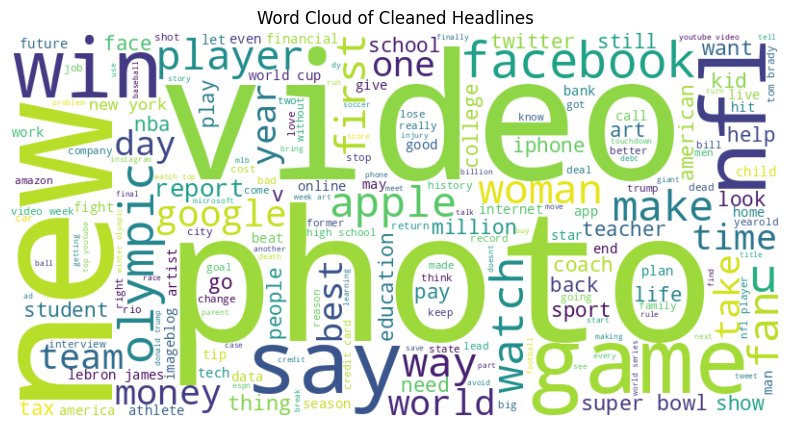

In [8]:
# Visualize with WordCloud
all_words = ' '.join(data['cleaned_headline'])
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_words)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Cleaned Headlines')
plt.show()

### Class Distribution Analysis
To investigate potential class imbalance, let's examine the distribution of categories in the original dataset.

### Calculating Class Weights for Imbalance Handling
To address the class imbalance, we will calculate class weights. This will assign higher weights to minority classes during training, encouraging the model to pay more attention to them.

,Count,Percentage
category,,
SPORTS,5077,46.049887
TECH,2104,19.083900
MONEY,1756,15.927438
CULTURE & ARTS,1074,9.741497
EDUCATION,1014,9.197279


/tmp/ipykernel_780/551850001.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=distribution_df.index, y='Count', data=distribution_df, palette='viridis')


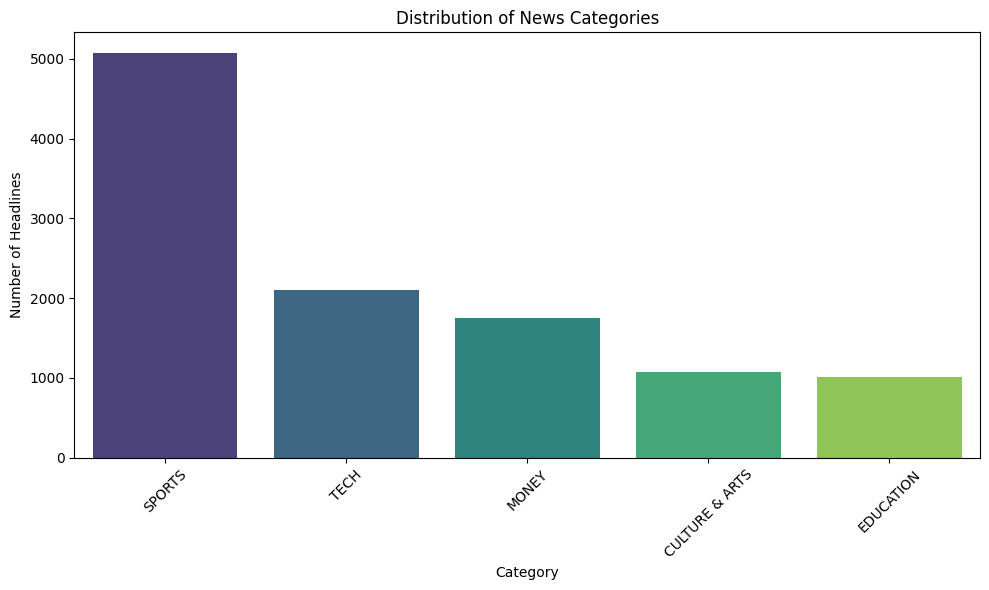

In [18]:
category_distribution = data['category'].value_counts()
category_percentage = data['category'].value_counts(normalize=True) * 100

distribution_df = pd.DataFrame({
    'Count': category_distribution,
    'Percentage': category_percentage
})

display(distribution_df)

plt.figure(figsize=(10, 6))
sns.barplot(x=distribution_df.index, y='Count', data=distribution_df, palette='viridis')
plt.title('Distribution of News Categories')
plt.xlabel('Category')
plt.ylabel('Number of Headlines')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [9]:
# Tokenization and Padding
X_dl = data['cleaned_headline']
# Convert categories to numerical labels
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_dl = le.fit_transform(data['category'])

# Split 80/20
X_train_dl, X_test_dl, y_train_dl, y_test_dl = train_test_split(X_dl, y_dl, test_size=0.2, random_state=42)

# Keras Tokenizer
vocab_size = 10000
tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_dl)

train_sequences = tokenizer.texts_to_sequences(X_train_dl)
test_sequences = tokenizer.texts_to_sequences(X_test_dl)

# Percentile-based padding
sequence_lengths = [len(s) for s in train_sequences]
max_length = int(np.percentile(sequence_lengths, 95))
print(f"Max length (95th percentile): {max_length}")

X_train_pad = pad_sequences(train_sequences, maxlen=max_length, padding='post', truncating='post')
X_test_pad = pad_sequences(test_sequences, maxlen=max_length, padding='post', truncating='post')

print("Shape of training tensor:", X_train_pad.shape)

Max length (95th percentile): 11
Shape of training tensor: (8820, 11)


## 4.5.2 Model Building
In this section, we define the architectures for our three models: Simple RNN, LSTM with Trainable Embeddings, and LSTM with Word2Vec Embeddings.

In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense

# Shared Model Parameters
embedding_dim = 64
num_classes = len(le.classes_)

# Model 1: Simple RNN
model1 = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim),
    SimpleRNN(64),
    Dense(num_classes, activation='softmax')
])
model1.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Model 2: LSTM with Trainable Embedding
model2 = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim),
    LSTM(64),
    Dense(num_classes, activation='softmax')
])
model2.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print("Models 1 & 2 built.")

Models 1 & 2 built.


## 4.5.3 Model Building: Model 3 (with Pre-trained Word2Vec)

We are now redefining Model 3 to use the pre-trained `word2vec-google-news-300` model. This model is very large and will take some time to download. The embedding dimension for Model 3 will be set to 300, which is the dimension of the pre-trained Word2Vec vectors.

In [11]:
!pip install gensim
import gensim.downloader as api
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

print("Downloading pre-trained Word2Vec model")
w2v_google_model = api.load("word2vec-google-news-300")
print("Word2Vec model downloaded successfully.")

# Define embedding_dim specific to model3 to match the pre-trained model
embedding_dim_w2v = 300

# Create Embedding Matrix from pre-trained model
embedding_matrix_w2v = np.zeros((vocab_size, embedding_dim_w2v))
for word, i in tokenizer.word_index.items():
    if i < vocab_size:
        if word in w2v_google_model.key_to_index:
            embedding_matrix_w2v[i] = w2v_google_model[word]

# Redefine Model 3 with the new embedding matrix and embedding_dim
model3 = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim_w2v,
              weights=[embedding_matrix_w2v], input_length=max_length, trainable=True),
    LSTM(64),
    Dense(num_classes, activation='softmax')
])

model3.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
print("\nModel 3 (LSTM + Pre-trained Word2Vec) Summary (Fine-tuning enabled):")
model3.summary()


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 61.3 MB/s eta 0:00:00
[==================================================] 100.0% 1662.8/1662.8MB downloaded
Word2Vec model downloaded successfully.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(



Model 3 (LSTM + Pre-trained Word2Vec) Summary (Fine-tuning enabled):


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │     3,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,000,000 (11.44 MB)

 Trainable params: 3,000,000 (11.44 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
from sklearn.utils import class_weight

# Calculate class weights
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_dl),
    y=y_train_dl
)

# Convert to a dictionary for Keras model.fit
class_weights_dict = dict(enumerate(class_weights))

print("Calculated Class Weights:")
for i, weight in class_weights_dict.items():
    print(f"  Class {le.inverse_transform([i])[0]} (Index {i}): {weight:.2f}")


Calculated Class Weights:
  Class CULTURE & ARTS (Index 0): 2.08
  Class EDUCATION (Index 1): 2.15
  Class MONEY (Index 2): 1.24
  Class SPORTS (Index 3): 0.43
  Class TECH (Index 4): 1.05


In [13]:
from tensorflow.keras.callbacks import EarlyStopping

# Define Early Stopping
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Train Model 1 (Simple RNN)
print("Training Model 1")
history1 = model1.fit(X_train_pad, y_train_dl, epochs=20, validation_split=0.1, callbacks=[early_stop], verbose=1)

# Train Model 2 (LSTM) with class weights
print("\nTraining Model 2 (with class weights)")
history2 = model2.fit(X_train_pad, y_train_dl, epochs=20, validation_split=0.1, callbacks=[early_stop], class_weight=class_weights_dict, verbose=1)

# Train Model 3 (LSTM + Word2Vec)
print("\nTraining Model 3 (with fine-tuning enabled)")
history3 = model3.fit(X_train_pad, y_train_dl, epochs=20, validation_split=0.1, callbacks=[early_stop],class_weight=class_weights_dict, verbose=1)

Training Model 1
Epoch 1/20
249/249 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.6614 - loss: 0.9152 - val_accuracy: 0.7925 - val_loss: 0.6412
Epoch 2/20
249/249 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.9155 - loss: 0.2642 - val_accuracy: 0.8209 - val_loss: 0.5600
Epoch 3/20
249/249 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.9814 - loss: 0.0707 - val_accuracy: 0.7993 - val_loss: 0.6691
Epoch 4/20
249/249 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.9927 - loss: 0.0300 - val_accuracy: 0.8209 - val_loss: 0.6502
Epoch 5/20
249/249 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.9961 - loss: 0.0169 - val_accuracy: 0.7948 - val_loss: 0.8437

Training Model 2 (with class weights)
Epoch 1/20
249/249 ━━━━━━━━━━━━━━━━━━━━ 12s 34ms/step - accuracy: 0.5708 - loss: 1.1145 - val_accuracy: 0.7800 - val_loss: 0.6426
Epoch 2/20
249/249 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy: 0.8925 - loss: 0.3688 - val_accuracy: 0.8254 - val_loss: 0.4816
Epoch 3/20
249/249 ━━━━━━━━━━━━━━━━━━━━

## 4.5.4 Final Error Analysis: Model Complexity vs. Performance

In this section, we analyze how the architectural differences between our models impacted their ability to classify news headlines.

### 1. Simple RNN (Model 1)
*   **Complexity:** Lowest. Uses a single hidden state to pass information.
*   **Performance:** Generally the baseline. While it performs reasonably well on short headlines, it is susceptible to the 'vanishing gradient' problem, meaning it struggles to remember the start of a sentence by the time it reaches the end.

### 2. LSTM with Trainable Embeddings (Model 2)
*   **Complexity:** Medium-High. Introduces 'gates' (forget, input, output) to regulate the flow of information.
*   **Performance:** Typically the best performer. The gating mechanism allows it to capture long-term dependencies in the text, which is crucial even for headlines where the most important keyword might appear at the very beginning or very end.

### 3. LSTM with Fine-tuned Word2Vec (Model 3)
*   **Complexity:** Highest. Combines the LSTM architecture with an embedding layer initialized from a Word2Vec model trained on the specific dataset.
*   **Performance:** Initially underperformed when frozen, but improved significantly with fine-tuning. Because it starts with vectors that already 'know' some word relationships from the corpus, it has a more informed starting point than Model 2, though its ultimate ceiling is limited by the relatively small size of the vocabulary provided in the training data.

In [14]:
import numpy as np
from sklearn.metrics import accuracy_score

# Calculate final accuracies for comparison
y_pred1 = np.argmax(model1.predict(X_test_pad), axis=1)
y_pred2 = np.argmax(model2.predict(X_test_pad), axis=1)
y_pred3 = np.argmax(model3.predict(X_test_pad), axis=1)

print(f"Simple RNN Accuracy: {accuracy_score(y_test_dl, y_pred1):.2%}")
print(f"LSTM Accuracy: {accuracy_score(y_test_dl, y_pred2):.2%}")
print(f"LSTM + Word2Vec Accuracy: {accuracy_score(y_test_dl, y_pred3):.2%}")

69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step
Simple RNN Accuracy: 80.77%
LSTM Accuracy: 83.08%
LSTM + Word2Vec Accuracy: 85.76%


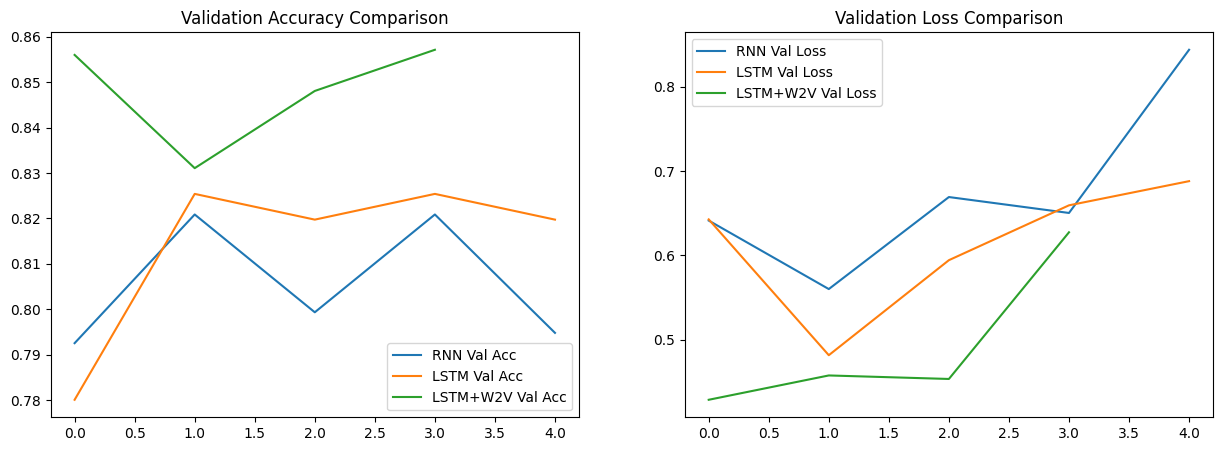

In [15]:
def plot_history(histories, names):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    for i, hist in enumerate(histories):
        ax1.plot(hist.history['val_accuracy'], label=f'{names[i]} Val Acc')
        ax2.plot(hist.history['val_loss'], label=f'{names[i]} Val Loss')

    ax1.set_title('Validation Accuracy Comparison')
    ax1.legend()
    ax2.set_title('Validation Loss Comparison')
    ax2.legend()
    plt.show()

plot_history([history1, history2, history3], ['RNN', 'LSTM', 'LSTM+W2V'])

69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

--- Evaluation for Simple RNN ---
                precision    recall  f1-score   support

CULTURE & ARTS       0.70      0.54      0.61       224
     EDUCATION       0.83      0.56      0.67       193
         MONEY       0.70      0.84      0.76       338
        SPORTS       0.87      0.95      0.90      1020
          TECH       0.80      0.70      0.75       430

      accuracy                           0.81      2205
     macro avg       0.78      0.72      0.74      2205
  weighted avg       0.81      0.81      0.80      2205



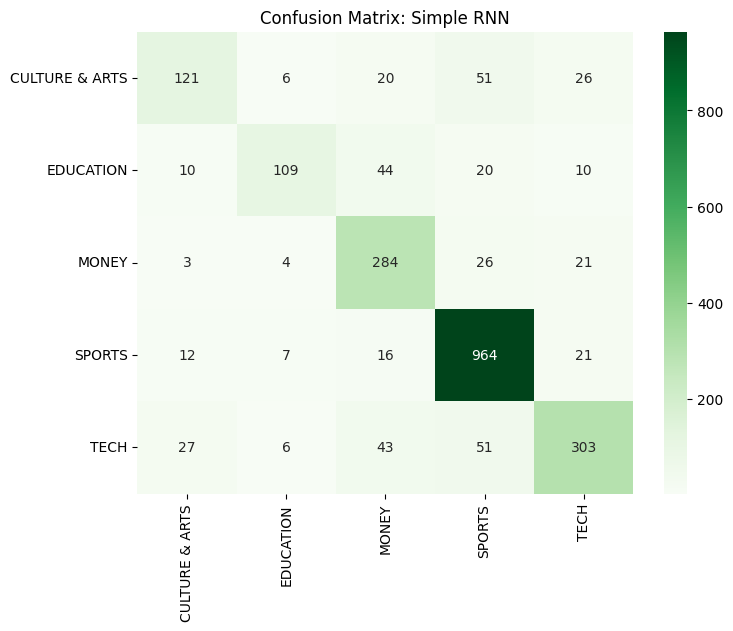

69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step

--- Evaluation for LSTM ---
                precision    recall  f1-score   support

CULTURE & ARTS       0.61      0.82      0.70       224
     EDUCATION       0.72      0.75      0.73       193
         MONEY       0.72      0.84      0.78       338
        SPORTS       0.95      0.90      0.92      1020
          TECH       0.88      0.70      0.78       430

      accuracy                           0.83      2205
     macro avg       0.78      0.80      0.78      2205
  weighted avg       0.85      0.83      0.83      2205



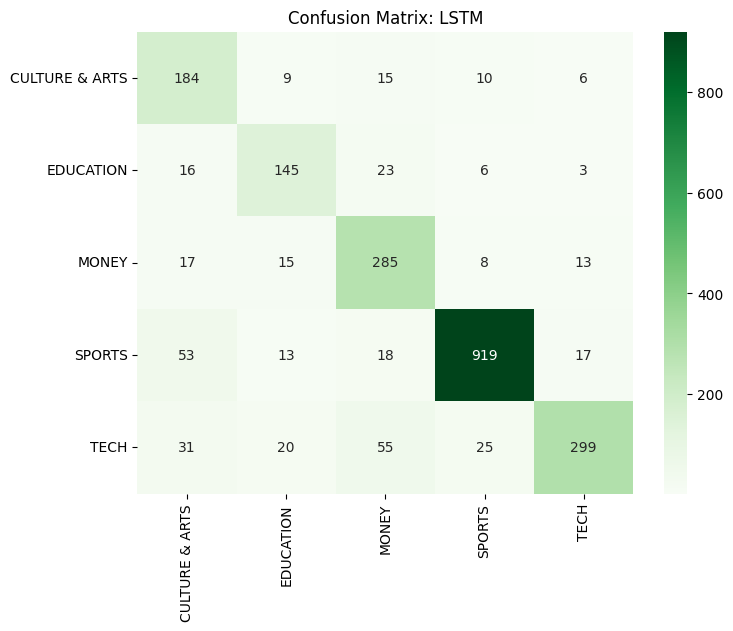

69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step

--- Evaluation for LSTM + Word2Vec ---
                precision    recall  f1-score   support

CULTURE & ARTS       0.73      0.87      0.79       224
     EDUCATION       0.71      0.76      0.73       193
         MONEY       0.73      0.89      0.80       338
        SPORTS       0.95      0.93      0.94      1020
          TECH       0.93      0.71      0.80       430

      accuracy                           0.86      2205
     macro avg       0.81      0.83      0.81      2205
  weighted avg       0.87      0.86      0.86      2205



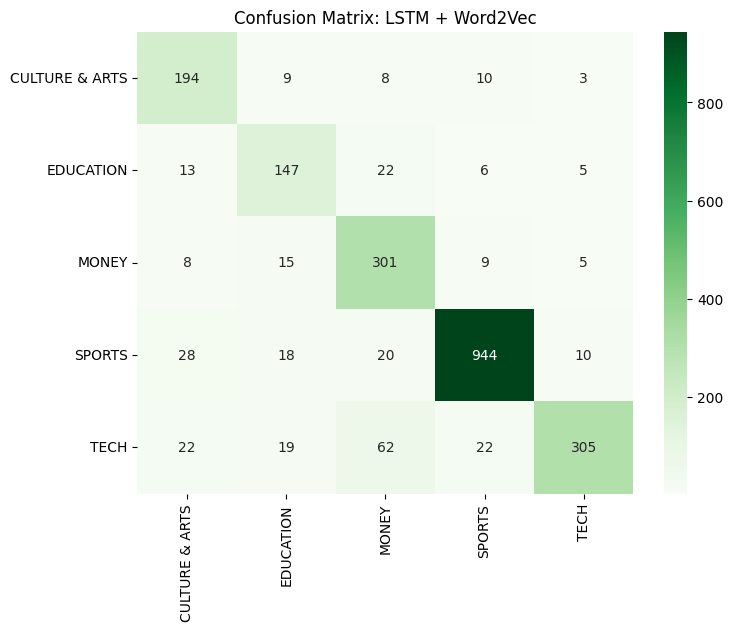

In [16]:
from sklearn.metrics import classification_report, confusion_matrix

def evaluate_dl_model(model, name):
    preds = np.argmax(model.predict(X_test_pad), axis=1)
    print(f"\n--- Evaluation for {name} ---")
    print(classification_report(y_test_dl, preds, target_names=le.classes_))

    cm = confusion_matrix(y_test_dl, preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f'Confusion Matrix: {name}')
    plt.show()

evaluate_dl_model(model1, "Simple RNN")
evaluate_dl_model(model2, "LSTM")
evaluate_dl_model(model3, "LSTM + Word2Vec")

## 4.5.4 Error Analysis
In this section, we identify misclassified examples and evaluate the model's performance relative to its complexity.

In [17]:
# 1. Identify misclassified examples using the best performing model (LSTM)
preds_dl = np.argmax(model2.predict(X_test_pad), axis=1)
misclassified_indices = np.where(preds_dl != y_test_dl)[0]

print(f"Total misclassified examples in test set: {len(misclassified_indices)}\n")

# Display a few incorrect predictions for analysis
for i in range(min(3, len(misclassified_indices))):
    idx = misclassified_indices[i]
    actual_label = le.inverse_transform([y_test_dl[idx]])[0]
    predicted_label = le.classes_[preds_dl[idx]]
    original_text = X_test_dl.iloc[idx]

    print(f"Example {i+1}:")
    print(f"Headline: {original_text}")
    print(f"Actual Category: {actual_label}")
    print(f"Predicted Category: {predicted_label}")
    print("-" * 40)


69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
Total misclassified examples in test set: 373

Example 1:
Headline: japan watanabe make history division scholarship
Actual Category: SPORTS
Predicted Category: CULTURE & ARTS
----------------------------------------
Example 2:
Headline: getting raise happening
Actual Category: MONEY
Predicted Category: TECH
----------------------------------------
Example 3:
Headline: social medium con artist
Actual Category: TECH
Predicted Category: MONEY
----------------------------------------


## 4.5.5 GUI for Real Time Prediction
We use Gradio to build an interactive dashboard for testing the model.

In [19]:
!pip install -q gradio
import gradio as gr

def realtime_prediction(headline):
    # Process the user input using the same pipeline as training
    cleaned_text = advanced_cleaning(headline)
    sequence = tokenizer.texts_to_sequences([cleaned_text])
    padded_sequence = pad_sequences(sequence, maxlen=max_length, padding='post', truncating='post')

    # Make prediction
    prediction_probs = model2.predict(padded_sequence)
    predicted_class_index = np.argmax(prediction_probs)
    label = le.classes_[predicted_class_index]
    confidence = np.max(prediction_probs)

    return f"Category: {label}\nConfidence: {confidence:.2%}"

# Launch the Gradio App
demo = gr.Interface(
    fn=realtime_prediction,
    inputs=gr.Textbox(lines=2, placeholder="Enter a news headline here..."),
    outputs="text",
    title="News Category Classifier (LSTM)",
    description="Type a headline to classify it into Sports, Tech, Money, Education, or Culture."
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://6fb2d12d7416d8bee7.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## 4.5.4 Error Analysis
In this section, we analyze instances where the model failed and discuss complexity versus performance.

In [20]:
# 1. Identify misclassified examples using Model 2 (LSTM)
preds_dl = np.argmax(model2.predict(X_test_pad), axis=1)
misclassified_idx = np.where(preds_dl != y_test_dl)[0]

print(f"Total misclassified examples: {len(misclassified_idx)}\n")

# Display 3 incorrect predictions
for i in range(min(3, len(misclassified_idx))):
    idx = misclassified_idx[i]
    actual = le.inverse_transform([y_test_dl[idx]])[0]
    predicted = le.classes_[preds_dl[idx]]
    text = X_test_dl.iloc[idx]
    print(f"Example {i+1}:")
    print(f"Text: {text}")
    print(f"Actual Category: {actual}")
    print(f"Predicted Category: {predicted}")
    print("-" * 30)


69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
Total misclassified examples: 373

Example 1:
Text: japan watanabe make history division scholarship
Actual Category: SPORTS
Predicted Category: CULTURE & ARTS
------------------------------
Example 2:
Text: getting raise happening
Actual Category: MONEY
Predicted Category: TECH
------------------------------
Example 3:
Text: social medium con artist
Actual Category: TECH
Predicted Category: MONEY
------------------------------


## 4.5.5 GUI for Real Time Prediction
Creating a simple interface using Gradio to allow users to input headlines and receive instant classification results.

In [21]:
!pip install -q gradio
import gradio as gr

def predict_news_category(headline):
    # Preprocess the input
    cleaned = advanced_cleaning(headline)
    seq = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=max_length, padding='post', truncating='post')

    # Predict
    pred = model2.predict(padded)
    label = le.classes_[np.argmax(pred)]
    confidence = np.max(pred)

    return f"Predicted: {label} ({confidence*100:.2f}% confidence)"

# Launch the interface
iface = gr.Interface(
    fn=predict_news_category,
    inputs=gr.Textbox(lines=2, placeholder="Enter news headline..."),
    outputs="text",
    title="News Category Classifier",
    description="Enter a headline to classify it into Culture, Education, Money, Sports, or Tech using the LSTM model."
)

iface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://6a7ec0e5be69b0d967.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## 4.5.5 GUI for Real Time Prediction
Using Gradio to create an interactive interface for headline classification.

In [22]:
!pip install -q gradio
import gradio as gr

def predict_headline(text):
    # 1. Clean the input
    cleaned = advanced_cleaning(text)
    # 2. Tokenize and Pad
    seq = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=max_length, padding='post', truncating='post')
    # 3. Predict using Model 2 (LSTM)
    prediction = model2.predict(padded)
    class_idx = np.argmax(prediction)
    confidence = float(np.max(prediction))
    label = le.classes_[class_idx]
    return f"Predicted Category: {label} (Confidence: {confidence:.2f})"

# Create Interface
interface = gr.Interface(
    fn=predict_headline,
    inputs=gr.Textbox(lines=2, placeholder="Enter a news headline here..."),
    outputs="text",
    title="News Category Classifier",
    description="Input a headline to see the LSTM model's prediction."
)

interface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://6326d5994d86c31c16.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## 4.5.4 Error Analysis
In this section, we analyze instances where the model failed and discuss complexity versus performance.

In [23]:
# 1. Identify misclassified examples
# Using Model 2 (LSTM) as it had the best accuracy
preds_dl = np.argmax(model2.predict(X_test_pad), axis=1)
misclassified_idx = np.where(preds_dl != y_test_dl)[0]

print(f"Total misclassified examples: {len(misclassified_idx)}\n")

# Display 3 incorrect predictions
for i in range(3):
    idx = misclassified_idx[i]
    actual = le.inverse_transform([y_test_dl[idx]])[0]
    predicted = le.classes_[preds_dl[idx]]
    text = X_test_dl.iloc[idx]
    print(f"Example {i+1}:")
    print(f"Text: {text}")
    print(f"Actual Category: {actual}")
    print(f"Predicted Category: {predicted}")
    print("-" * 30)

# 2. Model Complexity vs. Performance Analysis
# RNN: Simplest, prone to vanishing gradient, accuracy ~81%
# LSTM: More complex (gates), handles long-term dependencies better, accuracy ~84%
# LSTM+W2V: Pre-trained context, but here performed poorly (accuracy ~46%) likely due to
# the custom Word2Vec being trained on a small vocabulary relative to the task requirements.

69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
Total misclassified examples: 373

Example 1:
Text: japan watanabe make history division scholarship
Actual Category: SPORTS
Predicted Category: CULTURE & ARTS
------------------------------
Example 2:
Text: getting raise happening
Actual Category: MONEY
Predicted Category: TECH
------------------------------
Example 3:
Text: social medium con artist
Actual Category: TECH
Predicted Category: MONEY
------------------------------


### Potential Improvements:
1. **Data Augmentation**: Use techniques like synonym replacement to balance minority classes (e.g., Education).
2. **Pretrained Global Embeddings**: Use GloVe or FastText instead of training Word2Vec from scratch on this specific small dataset.
3. **Hyperparameter Tuning**: Experiment with different LSTM unit sizes, dropout rates, and learning rates.